# 1️⃣ Import Libraries

In [10]:
import os
print(os.getcwd())

c:\Emotion Recognition Speech\notebooks


In [1]:
import os
import sys
sys.path.append("../")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# 2️⃣ Load Dataset

In [2]:
import os
import sys
sys.path.append(os.path.abspath("../"))

In [ ]:
from src.data_loader import load_RAVDNESS_data
dataset_path = "../data/raw/RAVDNESS"

print("Exists:", os.path.exists(dataset_path))
print("Folders:", os.listdir(dataset_path)[:5])

Exists: True
Folders: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']
Total audio files: 1440
Dataset Shape: (1440, 2)


,path,emotion
0,../data/raw/RAVDNESS\Actor_01\03-01-01-01-01-0...,neutral
1,../data/raw/RAVDNESS\Actor_01\03-01-01-01-01-0...,neutral
2,../data/raw/RAVDNESS\Actor_01\03-01-01-01-02-0...,neutral
3,../data/raw/RAVDNESS\Actor_01\03-01-01-01-02-0...,neutral
4,../data/raw/RAVDNESS\Actor_01\03-01-02-01-01-0...,calm


In [4]:
df = load_RAVDNESS_data(dataset_path)
print("Dataset Shape:", df.shape)

df.head()

Total audio files: 1440
Dataset Shape: (1440, 2)


,path,emotion
0,../data/raw/RAVDNESS\Actor_01\03-01-01-01-01-0...,neutral
1,../data/raw/RAVDNESS\Actor_01\03-01-01-01-01-0...,neutral
2,../data/raw/RAVDNESS\Actor_01\03-01-01-01-02-0...,neutral
3,../data/raw/RAVDNESS\Actor_01\03-01-01-01-02-0...,neutral
4,../data/raw/RAVDNESS\Actor_01\03-01-02-01-01-0...,calm


# 3️⃣ Emotion Distribution Visualization

C:\Users\Alisha\AppData\Local\Temp\ipykernel_4616\2440457639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


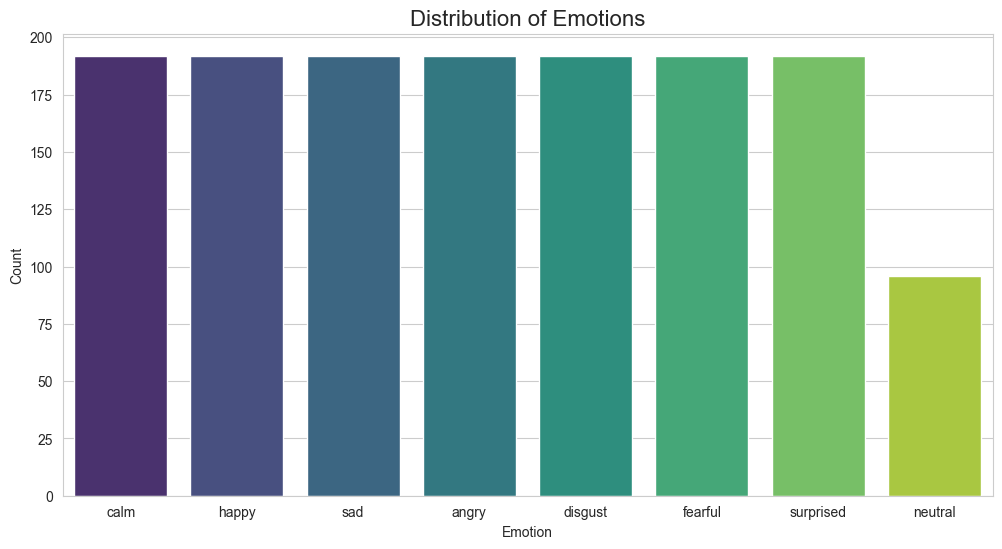

In [5]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="emotion",
    data=df,
    palette="viridis",
    order=df["emotion"].value_counts().index
)

plt.title("Distribution of Emotions", fontsize=16)
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

# 4️⃣ Pie Chart Visualization

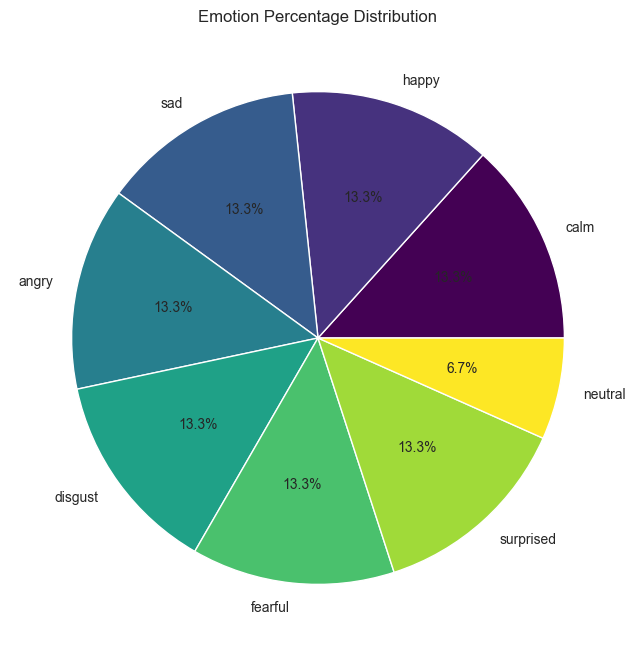

In [6]:
df["emotion"].value_counts().plot.pie(
    autopct="%1.1f%%",
    cmap="viridis",
    figsize=(8,8)
)

plt.title("Emotion Percentage Distribution")
plt.ylabel("")
plt.show()

# 5️⃣ Waveform Visualization

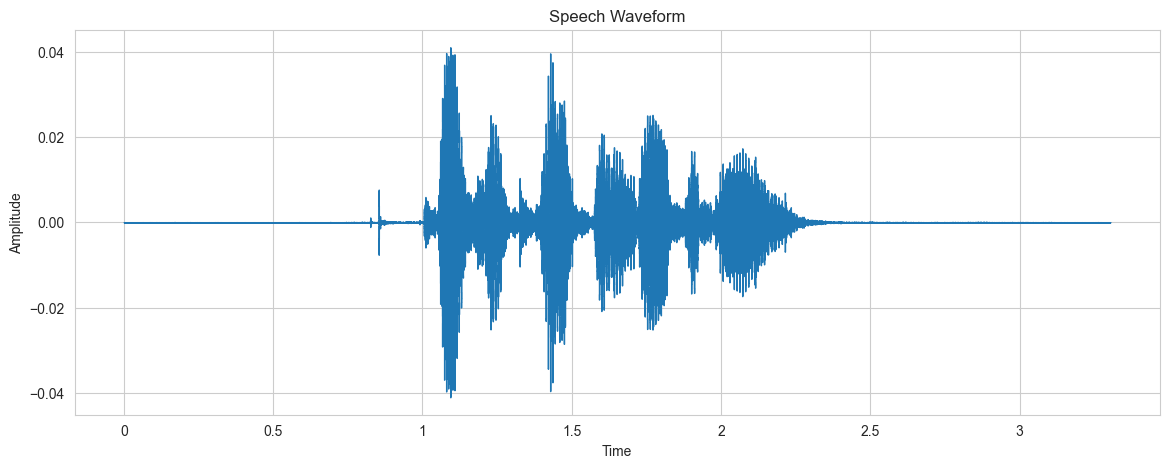

In [7]:
sample_path = df.iloc[0]["path"]

audio, sr = librosa.load(sample_path)

plt.figure(figsize=(14,5))

librosa.display.waveshow(audio, sr=sr)

plt.title("Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

# 6️⃣ Spectrogram Visualization

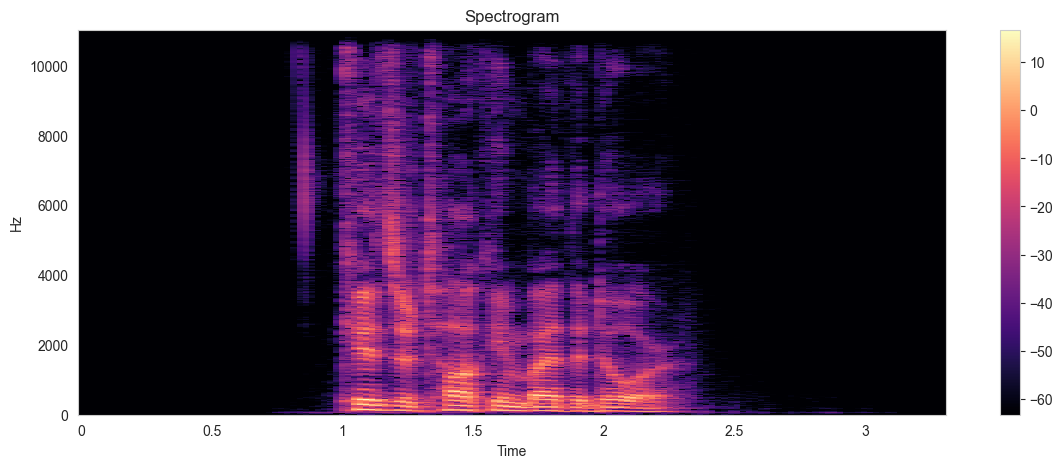

In [8]:
X = librosa.stft(audio)

Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(14,5))

librosa.display.specshow(Xdb, sr=sr, x_axis="time", y_axis="hz")

plt.colorbar()

plt.title("Spectrogram")

plt.show()

# 7️⃣ MFCC Visualization

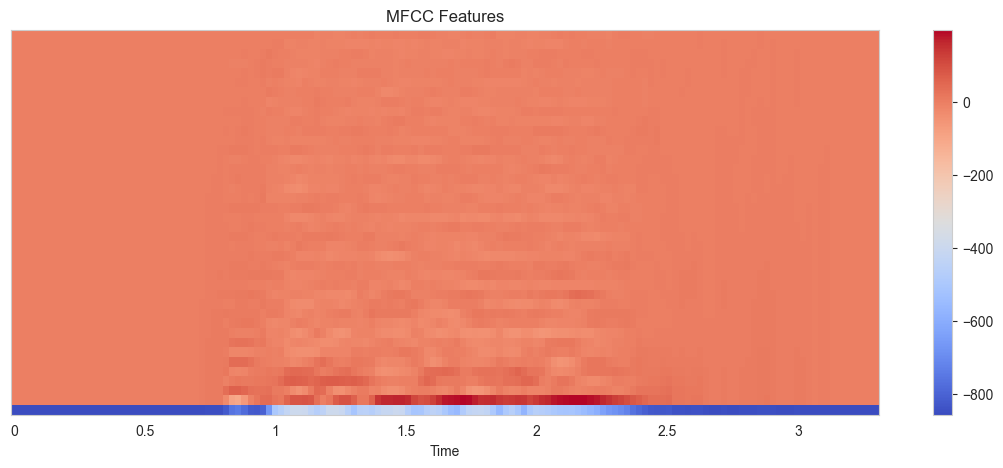

In [9]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

plt.figure(figsize=(14,5))

librosa.display.specshow(mfcc, x_axis="time")

plt.colorbar()

plt.title("MFCC Features")

plt.show()